# Jawad Hassan 2230-0035
# BS AI
# CV LAB # 2



In [2]:
!pip install numpy matplotlib pillow opencv-python

In [3]:
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and pick an image

Saving input_image.jpg to input_image.jpg


In [4]:
import os
os.rename(list(uploaded.keys())[0], 'input_image.jpg')

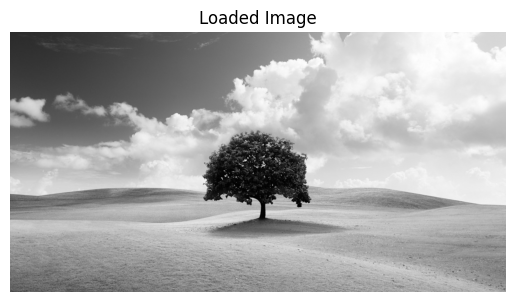

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('input_image.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title('Loaded Image')
plt.axis('off')
plt.show()

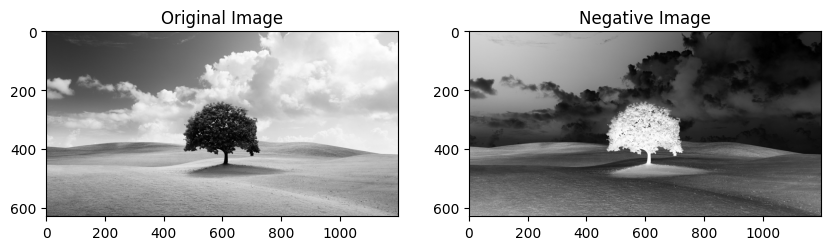

In [ ]:
#1. Image Negative Transformation Objective
negative_img = 255 - img

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Negative Image')
plt.imshow(negative_img, cmap='gray')
plt.show()

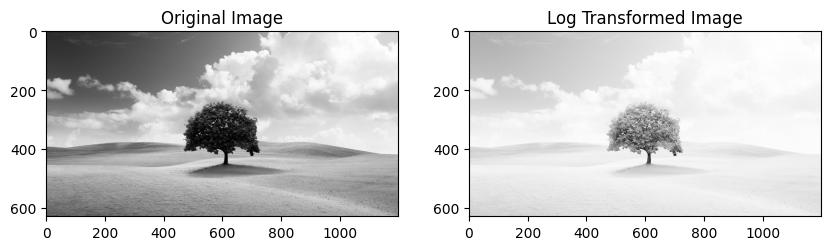

In [ ]:
#2. Log Transformation
img_float = img.astype(np.float64)

c = 255 / (np.log(1 + np.max(img_float)))
log_image = c * (np.log(1 + img_float))
log_image = np.array(log_image, dtype=np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Log Transformed Image')
plt.imshow(log_image, cmap='gray')
plt.show()

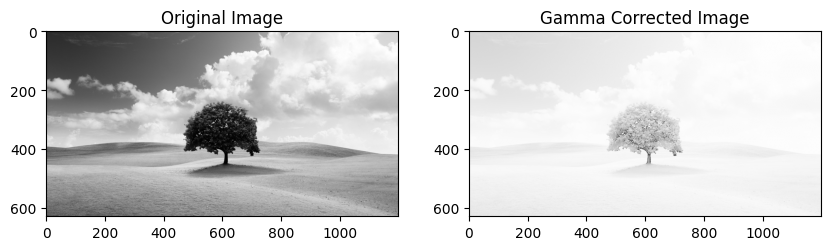

In [ ]:
#3. Power-Law (Gamma) Transformation Objective

gamma = 0.1
gamma_corrected = np.array(255 * (img / 255)**gamma, dtype='uint8')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Gamma Corrected Image')
plt.imshow(gamma_corrected, cmap='gray')
plt.show()

0
255


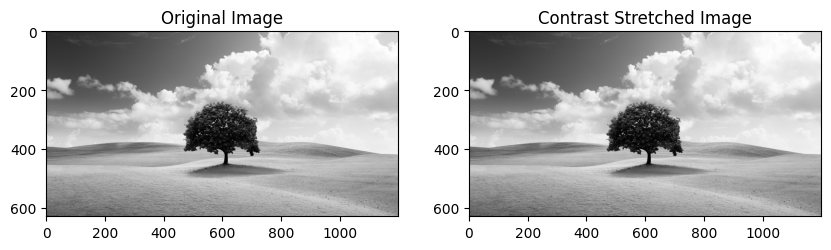

In [ ]:
# 4. Contrast Stretching
min_val = np.min(img)
max_val = np.max(img)
print(min_val)
print(max_val)
contrast_stretched = (img - min_val) * (255 / (max_val - min_val))
contrast_stretched = np.array(contrast_stretched, dtype=np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Contrast Stretched Image')
plt.imshow(contrast_stretched, cmap='gray')
plt.show()

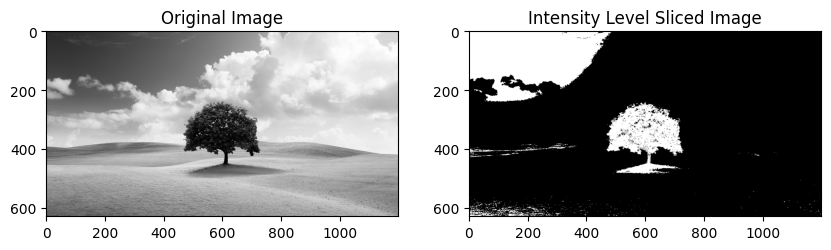

In [6]:
#5. Intensity Level Slicing
sliced_img = np.where((img >= 1) & (img <= 100), 255, 0).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Intensity Level Sliced Image')
plt.imshow(sliced_img, cmap='gray')
plt.show()

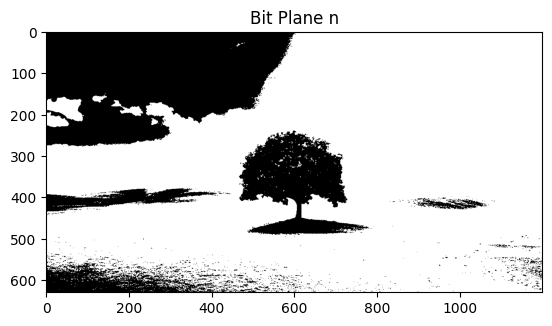

In [20]:
#6. Bit-Plane Slicing
n = 7
bit_plane_n = (img & (2**n)) >> n
plt.imshow(bit_plane_n * 255, cmap='gray')
plt.title('Bit Plane n')
plt.show()

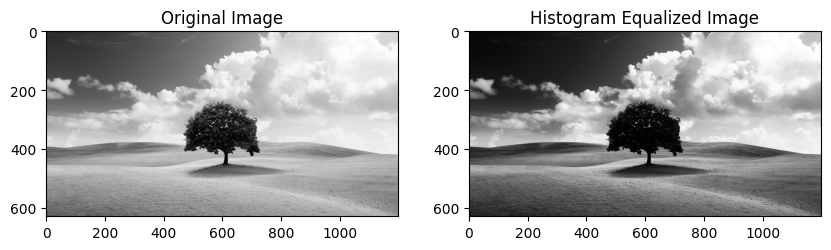

In [6]:
# 7. Histogram Equalization
equalized_img = cv2.equalizeHist(img)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Histogram Equalized Image')
plt.imshow(equalized_img, cmap='gray')
plt.show()

Saving input_image.avif to input_image.avif


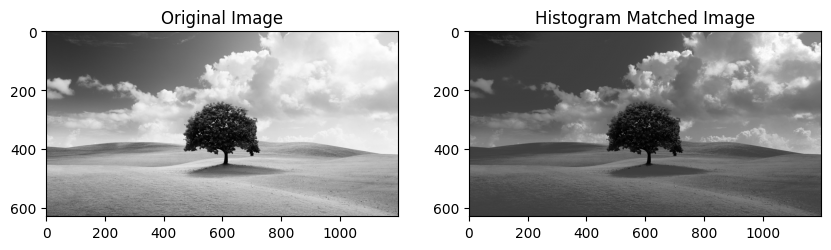

In [7]:
# 8. Histogram Matching
from google.colab import files
uploaded_ref = files.upload()
import os
os.rename(list(uploaded_ref.keys())[0], 'reference_image.jpg')

from skimage.exposure import match_histograms

reference_img = cv2.imread('reference_image.jpg', cv2.IMREAD_GRAYSCALE)
matched_img = match_histograms(img, reference_img, channel_axis=None)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Histogram Matched Image')
plt.imshow(matched_img, cmap='gray')
plt.show()

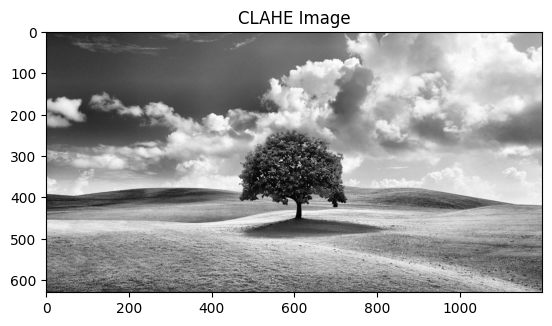

In [ ]:
#9. Local Histogram Equalization
clahe = cv2.createCLAHE(clipLimit=2.0,
tileGridSize=(8,8))
clahe_img = clahe.apply(img)

plt.imshow(clahe_img, cmap='gray')
plt.title('CLAHE Image')
plt.show()

Saving input_image.avif to input_image.avif


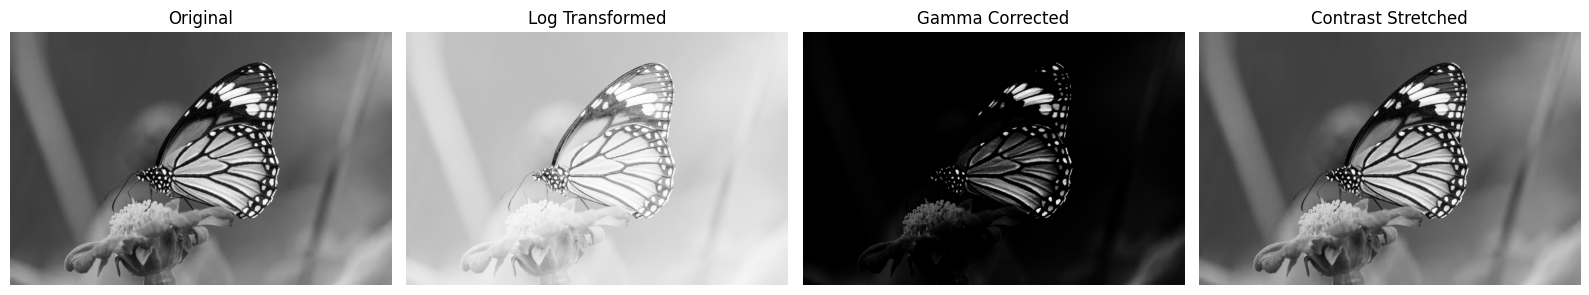

In [11]:
#Lab Tasks:
#1. Apply Multiple Intensity Transformations to Enhance Image Quality

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload a new image
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

img_float = img.astype(np.float64)

# Log transformation
c = 255 / (np.log(1 + np.max(img_float)))
log_image = c * (np.log(1 + img_float))
log_image = np.array(log_image, dtype=np.uint8)

# Gamma correction
gamma = 5
gamma_corrected = np.array(255 * (img / 255) ** gamma, dtype='uint8')

# Contrast stretching
min_val = np.min(img)
max_val = np.max(img)
contrast_stretched = (img - min_val) * (255 / (max_val - min_val))
contrast_stretched = np.array(contrast_stretched, dtype=np.uint8)

# Display all four in a single figure
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.title('Original')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title('Log Transformed')
plt.imshow(log_image, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title('Gamma Corrected')
plt.imshow(gamma_corrected, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title('Contrast Stretched')
plt.imshow(contrast_stretched, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Saving p3286591407-5-800x533.webp to p3286591407-5-800x533 (2).webp


/tmp/ipykernel_2415/2861194040.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(low_contrast_img.ravel(), 256, [0,256], color='gray')
/tmp/ipykernel_2415/2861194040.py:48: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(global_eq.ravel(), 256, [0,256], color='gray')
/tmp/ipykernel_2415/2861194040.py:52: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(local_eq.ravel(), 256, [0,256], color='gray')


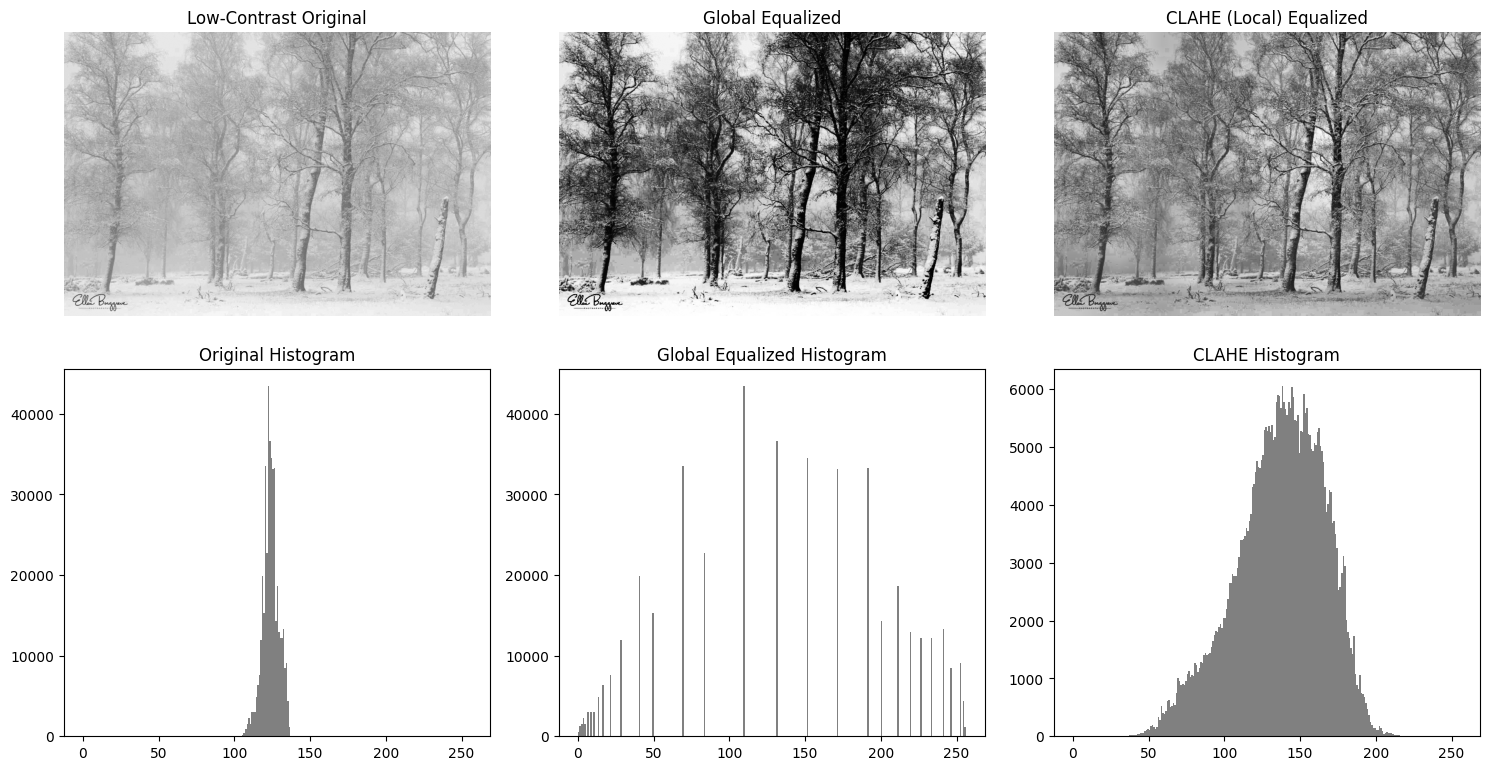

In [14]:
#2. Compare Global and Local Histogram Equalization

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload a new image
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Synthetically compress its range to simulate a low-contrast image
# (If you have your OWN actual low-contrast photo, just upload that above instead —
# this line will still run, but you can remove it if your uploaded photo is already low-contrast.)
low_contrast_img = np.array(80 + (img.astype(np.float64) / 255) * 70, dtype=np.uint8)

# Global histogram equalization
global_eq = cv2.equalizeHist(low_contrast_img)

# Local histogram equalization (CLAHE)
clahe = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(10,10))
local_eq = clahe.apply(low_contrast_img)

# Display images + histograms together
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.title('Low-Contrast Original')
plt.imshow(low_contrast_img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title('Global Equalized')
plt.imshow(global_eq, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title('CLAHE (Local) Equalized')
plt.imshow(local_eq, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.hist(low_contrast_img.ravel(), 256, [0,256], color='gray')
plt.title('Original Histogram')

plt.subplot(2,3,5)
plt.hist(global_eq.ravel(), 256, [0,256], color='gray')
plt.title('Global Equalized Histogram')

plt.subplot(2,3,6)
plt.hist(local_eq.ravel(), 256, [0,256], color='gray')
plt.title('CLAHE Histogram')

plt.tight_layout()
plt.show()